# Convolution from scratch

In [ ]:
import numpy as np
image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 2],
    [3, 0, 1, 2, 1],
    [2, 1, 3, 0, 0],
    [1, 2, 0, 1, 2]
])

image.shape

(5, 5)

In [ ]:
kernel = np.array([
    [0, 1, 0],
    [1, -4, 1],
    [0, 1, 0]
])


In [ ]:
def convolve(image, kernel):
    image_h, image_w = image.shape
    kernel_h, kernel_w = kernel.shape
    output_h = image_h - kernel_h + 1
    output_w = image_w - kernel_w + 1
    output = np.zeros((output_h, output_w))

    for i in range(output_h):
        for j in range(output_w):
            output[i, j] = np.sum(image[i:i+kernel_h, j:j+kernel_w] * kernel)

    return output


output = convolve(image, kernel)
print("Convolution Output:\n", output)

Convolution Output:
 [[  0.   0.  -6.]
 [  6.   3.  -3.]
 [  3. -10.   6.]]


# Padding with stride = 1

1. Padding: Zero-padding is added to the image to control the spatial dimensions of the output.
2. Stride: Controls how much the filter moves at each step. A stride of 1 means the filter moves one pixel at a time.
3. Convolution with Padding and Stride: The output is now controlled by the padding and stride, allowing us to maintain or reduce the spatial dimensions of the output.

In [ ]:
def pad_image(image, pad):
    return np.pad(image, pad, mode='constant', constant_values=100) # padding with 100, just to show.

pad_image(image, 1)

array([[100, 100, 100, 100, 100, 100, 100],
       [100,   1,   2,   3,   0,   1, 100],
       [100,   0,   1,   2,   3,   2, 100],
       [100,   3,   0,   1,   2,   1, 100],
       [100,   2,   1,   3,   0,   0, 100],
       [100,   1,   2,   0,   1,   2, 100],
       [100, 100, 100, 100, 100, 100, 100]])

In [ ]:
def convolve_with_padding_and_stride(image, kernel, stride=1, padding=0):
    if padding > 0:
        image = pad_image(image, padding)

    image_h, image_w = image.shape
    kernel_h, kernel_w = kernel.shape
    output_h = (image_h - kernel_h) // stride + 1
    output_w = (image_w - kernel_w) // stride + 1
    output = np.zeros((output_h, output_w))

    for i in range(0, output_h * stride, stride):
        for j in range(0, output_w * stride, stride):
            output[i // stride, j // stride] = np.sum(
                image[i:i+kernel_h, j:j+kernel_w] * kernel
            )

    return output

image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 2],
    [3, 0, 1, 2, 1],
    [2, 1, 3, 0, 0],
    [1, 2, 0, 1, 2]
])

padded_output = convolve_with_padding_and_stride(image, kernel, stride=1, padding=1)
print("Padded Convolution Output:\n", padded_output)


Padded Convolution Output:
 [[198.  97.  92. 107. 198.]
 [105.   0.   0.  -6.  97.]
 [ 90.   6.   3.  -3. 100.]
 [ 97.   3. -10.   6. 103.]
 [200.  94. 106.  98. 193.]]


In [ ]:
# Max Pooling function
def max_pooling(image, pool_size, stride):
    image_h, image_w = image.shape
    output_h = (image_h - pool_size) // stride + 1
    output_w = (image_w - pool_size) // stride + 1
    output = np.zeros((output_h, output_w))

    for i in range(0, output_h * stride, stride):
        for j in range(0, output_w * stride, stride):
            output[i // stride, j // stride] = np.max(
                image[i:i+pool_size, j:j+pool_size]
            )

    return output


image = np.array([
    [1, 2, 3, 0, 1],
    [0, 1, 2, 3, 2],
    [3, 0, 1, 2, 1],
    [2, 1, 3, 0, 0],
    [1, 2, 0, 1, 2]
])
# Apply max pooling
pooled_output = max_pooling(image, pool_size=2, stride=2)
print("Max Pooling Output:\n", pooled_output)


Max Pooling Output:
 [[2. 3.]
 [3. 3.]]


# Convolution on RGB Images

In [ ]:
# Define a simple 5x5x3 RGB image (3 channels)
image = np.array([
    [[1, 0, 2], [2, 1, 1], [3, 2, 0], [0, 1, 1], [1, 0, 2]],
    [[0, 1, 0], [1, 0, 1], [2, 2, 2], [3, 1, 3], [2, 0, 1]],
    [[3, 0, 2], [0, 1, 0], [1, 0, 1], [2, 2, 2], [1, 0, 0]],
    [[2, 1, 1], [1, 0, 2], [3, 3, 1], [0, 1, 0], [0, 2, 1]],
    [[1, 2, 2], [2, 1, 0], [0, 0, 1], [1, 2, 2], [2, 1, 1]]
])

image.shape

(5, 5, 3)

In [ ]:
# Define a 3x3x3 filter (kernel) for each channel (RGB)
kernel = np.array([
    [[0, 1, 0], [1, -1, 1], [0, 1, 0]],
    [[1, 0, 1], [0, -1, 0], [1, 0, 1]],
    [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
])

kernel.shape

(3, 3, 3)

In [ ]:
image_h, image_w, image_c = image.shape

print(image_h, image_w, image_c)
kernel_h, kernel_w, kernel_c = kernel.shape
print(kernel_h, kernel_w, kernel_c )
output_h = image_h - kernel_h + 1
output_w = image_w - kernel_w + 1
output = np.zeros((output_h, output_w, 1))
output.shape

5 5 3
3 3 3


(3, 3, 1)

In [ ]:
for k in range(image_c):  # Apply the convolution for each channel
        for i in range(output_h):
            for j in range(output_w):
                # print(np.sum(image[i:i+kernel_h, j:j+kernel_w, k] * kernel))
                output[i, j] = np.sum(image[i:i+kernel_h, j:j+kernel_w, k] * kernel)
                # break
            # break
        # break
output

array([[[10.],
        [12.],
        [12.]],

       [[16.],
        [15.],
        [11.]],

       [[ 8.],
        [11.],
        [15.]]])

# Implementing the same with Keras

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# Example input shape for a 32x32 RGB image
input_shape = (100, 100, 3)

# Define the model
model = models.Sequential()

# Add Input layer
model.add(layers.Input(shape=input_shape))

# Adding Convolution Layer
model.add(layers.Conv2D(16, (3, 3), padding='same', strides=1, activation='relu'))

# Adding Max Pooling Layer
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))

# Adding more convolutional and pooling layers as needed
model.add(layers.Conv2D(32, (3, 3), padding='same', strides=1, activation='relu'))
model.add(layers.MaxPooling2D(pool_size=(2, 2), strides=2))

# Print model summary to see the structure
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,088 (19.88 KB)

 Trainable params: 5,088 (19.88 KB)

 Non-trainable params: 0 (0.00 B)

### 1 : Create an image X that contains diagonal edges (i.e., a matrix where the values form a diagonal pattern). Now apply a kernel K(choose any) to this image. Answer the following sub-questions:

* What happens to the image X when the kernel K is applied? Explain the result.
* What happens if you transpose the image X before applying the kernel K? How does this affect the result?
* What happens if you transpose the kernel K and apply it to the original image X? What differences do you observe compared to applying the original kernel?

In [1]:
!wget -O diagonal_stripes_pattern.jpg "https://image.shutterstock.com/image-vector/black-white-diagonal-stripes-pattern-260nw-1932583061.jpg"

--2026-07-05 10:29:30--  https://image.shutterstock.com/image-vector/black-white-diagonal-stripes-pattern-260nw-1932583061.jpg
Resolving image.shutterstock.com (image.shutterstock.com)... 99.84.132.16, 99.84.132.44, 99.84.132.19, ...
Connecting to image.shutterstock.com (image.shutterstock.com)|99.84.132.16|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 63687 (62K) [image/jpeg]
Saving to: ‘diagonal_stripes_pattern.jpg’

diagonal_stripes_pa 100%[===================>]  62.19K  --.-KB/s    in 0.01s   

2026-07-05 10:29:30 (5.39 MB/s) - ‘diagonal_stripes_pattern.jpg’ saved [63687/63687]



In [2]:
!wget -O diagonal_stripes_pattern_1.jpg "https://media.istockphoto.com/id/528685339/vector/seamless-pattern.jpg?s=612x612&w=0&k=20&c=0JGLEXv5HPfl2GkTEOlcLg5VEpoD2i55Fh-5AU1ZfIA="

--2026-07-05 10:29:36--  https://media.istockphoto.com/id/528685339/vector/seamless-pattern.jpg?s=612x612&w=0&k=20&c=0JGLEXv5HPfl2GkTEOlcLg5VEpoD2i55Fh-5AU1ZfIA=
Resolving media.istockphoto.com (media.istockphoto.com)... 54.230.253.9, 54.230.253.40, 54.230.253.88, ...
Connecting to media.istockphoto.com (media.istockphoto.com)|54.230.253.9|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 121471 (119K) [image/jpeg]
Saving to: ‘diagonal_stripes_pattern_1.jpg’

diagonal_stripes_pa 100%[===================>] 118.62K  --.-KB/s    in 0.06s   

2026-07-05 10:29:36 (1.87 MB/s) - ‘diagonal_stripes_pattern_1.jpg’ saved [121471/121471]



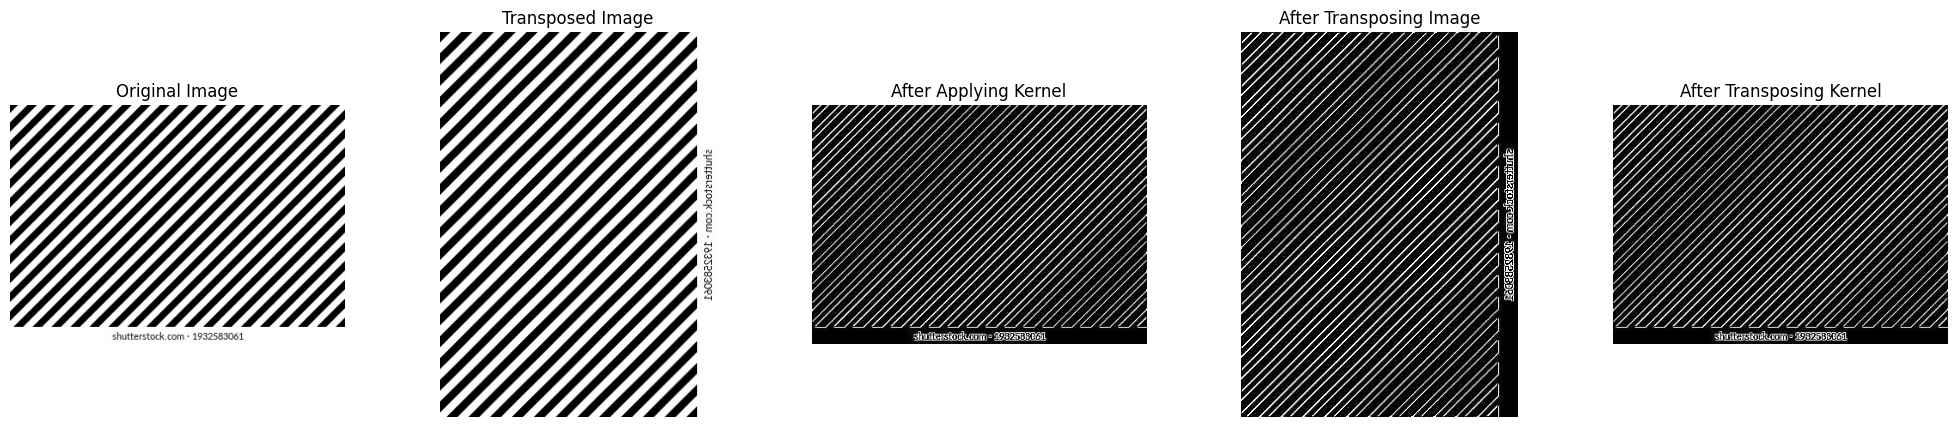

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the downloaded image
image = cv2.imread('diagonal_stripes_pattern.jpg', cv2.IMREAD_GRAYSCALE)

# Define a Kernel (e.g., simple edge detection kernel)
kernel = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]], dtype=np.float32)

# Function to convolve image with kernel
def convolve(image, kernel):
    return cv2.filter2D(image, -1, kernel)

# Apply Kernel to Original Image
convolved_original = convolve(image, kernel)

# Transpose the Image (Flip rows and columns)
image_transposed = np.transpose(image)

# Apply the Kernel to the Transposed Image
convolved_transposed_image = convolve(image_transposed, kernel)

# Transpose the Kernel and Apply to Original Image
kernel_transposed = np.transpose(kernel)
convolved_transposed_kernel = convolve(image, kernel_transposed)

# Visualization
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(image_transposed, cmap='gray')
axes[1].set_title('Transposed Image')
axes[1].axis('off')

axes[2].imshow(convolved_original, cmap='gray')
axes[2].set_title('After Applying Kernel')
axes[2].axis('off')

axes[3].imshow(convolved_transposed_image, cmap='gray')
axes[3].set_title('After Transposing Image')
axes[3].axis('off')

axes[4].imshow(convolved_transposed_kernel, cmap='gray')
axes[4].set_title('After Transposing Kernel')
axes[4].axis('off')

plt.show()


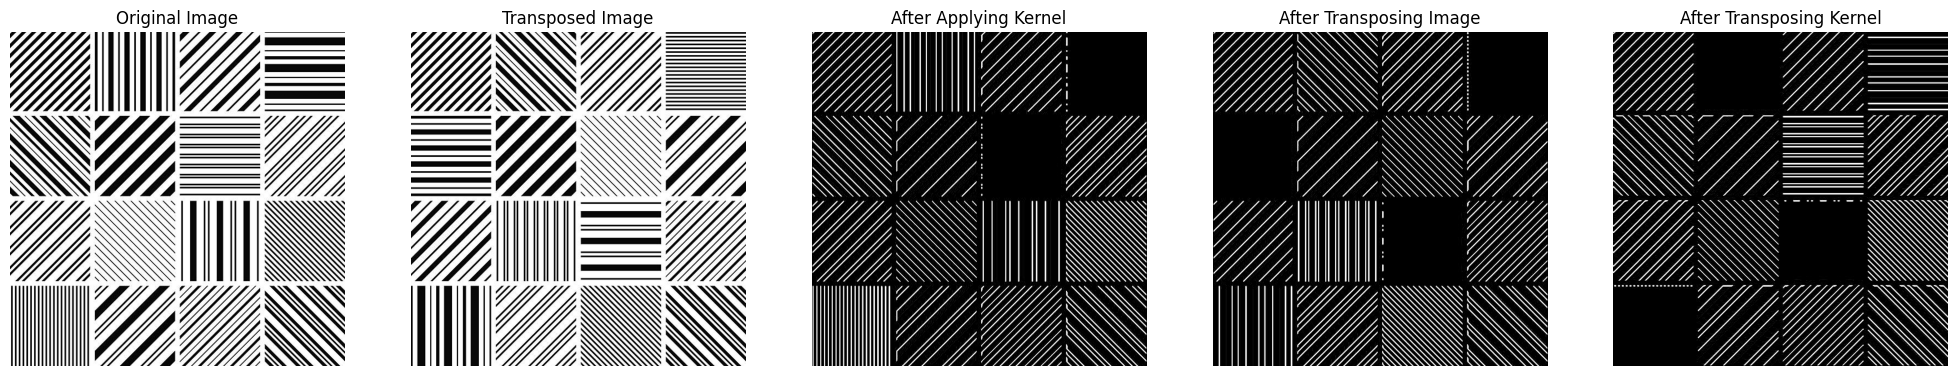

In [4]:
# Load the downloaded image
image = cv2.imread('diagonal_stripes_pattern_1.jpg', cv2.IMREAD_GRAYSCALE)

# Define a Kernel (e.g., simple edge detection kernel)
kernel = np.array([[1, 0,-1], [1, 0,-1]], dtype=np.float32)

# Function to convolve image with kernel
def convolve(image, kernel):
    return cv2.filter2D(image, -1, kernel)

# Apply Kernel to Original Image
convolved_original = convolve(image, kernel)

# Transpose the Image (Flip rows and columns)
image_transposed = np.transpose(image)

# Apply the Kernel to the Transposed Image
convolved_transposed_image = convolve(image_transposed, kernel)

# Transpose the Kernel and Apply to Original Image
kernel_transposed = np.transpose(kernel)
convolved_transposed_kernel = convolve(image, kernel_transposed)

# Visualization
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(image_transposed, cmap='gray')
axes[1].set_title('Transposed Image')
axes[1].axis('off')

axes[2].imshow(convolved_original, cmap='gray')
axes[2].set_title('After Applying Kernel')
axes[2].axis('off')

axes[3].imshow(convolved_transposed_image, cmap='gray')
axes[3].set_title('After Transposing Image')
axes[3].axis('off')

axes[4].imshow(convolved_transposed_kernel, cmap='gray')
axes[4].set_title('After Transposing Kernel')
axes[4].axis('off')

plt.show()
